In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('../')
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

RUN_DIR = "/cephfs/home/mkairov/gd_runs"

In [2]:
import torch
from torch import nn

from transformers import AutoConfig, AutoTokenizer
from safetensors.torch import load_file
from pathlib import Path
import json

from run_gradrmt_on_kv_retrieval import ExperimentArgs
from grad_rmt import GradRMT, GradRMTConfig

def prepare_model(run_path):
    # get best saved checkpoint
    best_score = -1
    best_cpt = None
    for cpt_path in Path(run_path).glob('**/checkpoint-*'):
        cpt_state = json.load(open(f'{cpt_path}/trainer_state.json'))
        cur_score = cpt_state['log_history'][-1]['eval_token_accuracy']
        if cur_score > best_score:
            best_score = cur_score
            best_cpt = str(cpt_path)

    # load args for original experiment
    CPT_PATH = f"{best_cpt}/model.safetensors"
    cli_config = json.load(open(f'{run_path}/config.json'))['cli_args']
    cli_config['init_checkpoint'] = CPT_PATH
    args = ExperimentArgs(**cli_config)

    # load/create backbone
    if args.pretrained_model is None:
        # create tokenizer
        tokenizer = AutoTokenizer.from_pretrained(args.tokenizer_path)
        # create base model config
        if args.base_model == 'gpt2':
            config = AutoConfig.from_pretrained('gpt2')
            config.n_layer = args.n_layer
            config.n_head = args.n_head
            config.n_embd = args.n_embd
        elif args.base_model == 'pythia':
            config = AutoConfig.from_pretrained('EleutherAI/pythia-160m')
            config.num_hidden_layers = args.n_layer
            config.num_attention_heads = args.n_head
            config.hidden_size = args.n_embd
            config.intermediate_size = config.hidden_size * 4
        elif args.base_model == 'llama':
            # config = AutoConfig.from_pretrained('meta-llama/Llama-3.2-1B')
            config = AutoConfig.from_pretrained('unsloth/Llama-3.2-1B')
            config.num_hidden_layers = args.n_layer
            config.num_attention_heads = args.n_head
            config.num_key_value_heads = args.n_head
            config.hidden_size = args.n_embd
            config.head_dim = config.hidden_size // config.num_attention_heads
            config.intermediate_size = config.hidden_size * 4
        else:
            raise ValueError(f'Unsupported base model: {args.base_model}')
        
        config.torch_dtype = "float32"  # weights in float32, at training precision is controlled by accelerate
        config.vocab_size = tokenizer.vocab_size
        config.pad_token_id = tokenizer.pad_token_id
        config.bos_token_id = tokenizer.bos_token_id
        config.eos_token_id = tokenizer.eos_token_id
        config.use_cache = False

    else:
        config = None
        tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model)
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token_id = tokenizer.eos_token_id

    # initialize GradRMT model
    gradrmt_config = GradRMTConfig(pretrained_model=args.pretrained_model, base_config=config,
                                        n_mem_tokens=args.n_mem_tokens, K=args.K,
                                        last_K_second_order=args.last_K_second_order,
                                        lr=args.inner_lr, learn_lr=args.learn_lr, inner_optim=args.inner_optim,
                                        grad_mode=args.grad_mode, momentum_mode=args.momentum_mode,
                                        n_ctrl_tokens=args.n_ctrl_tokens,
                                        inner_clip_value=args.inner_clip_value, inner_clip_norm=args.inner_clip_norm,
                                        use_mem_proj=args.use_mem_proj, mem_proj_mode=args.mem_proj_mode,
                                        use_write_head=args.use_write_head, segment_size=args.segment_size,
                                        use_mem_attn=args.use_mem_attn, use_retrieval=args.use_retrieval,
                                        use_gradient_checkpointing=args.use_gradient_checkpointing)

    # Create gradmemgpt model
    model = GradRMT(gradrmt_config)

    # load existing checkpoint
    if args.init_checkpoint is not None:
        missing_k, unexpected_k = model.load_state_dict(load_file(args.init_checkpoint), strict=False)
        if len(missing_k) != 0:
            print(f'{missing_k} were not loaded from checkpoint! These parameters were randomly initialized.')
        if len(unexpected_k) != 0:
            print(f'{unexpected_k} were found in checkpoint, but model is not expecting them!')
        model.model.tie_weights()
    
    return model, tokenizer, args


2025-11-01 03:10:11,267 - root - INFO - CUDA DEVICE COUNT: 1


In [3]:
from kv_dataset_utils import BASE_KV_ALPHABET
import random

def generate_sequence(num_kv_pairs=32, k_length=2, v_length=2, n_segments=4, kv_alphabet=BASE_KV_ALPHABET):
    # generate unique keys and values
    # return context + queries from each segment
    keys = []
    values = []
    for _ in range(num_kv_pairs):
        while True:
            key = ''.join(random.choice(kv_alphabet) for _ in range(k_length))
            if key not in keys:
                break
        value = ''.join(random.choice(kv_alphabet) for _ in range(v_length))
        keys.append(key)
        values.append(value)
    
    kv_pairs = [f'!{k}:{v}!' for k, v in zip(keys, values)]
    context = ''.join(kv_pairs)

    query_idx = [random.randint(seg_num * num_kv_pairs // n_segments, (seg_num + 1) * num_kv_pairs // n_segments - 1) for seg_num in range(n_segments)]
    queries = [keys[query_id] for query_id in query_idx]
    targets = [values[query_id] for query_id in query_idx]
    
    return {'context': context, 'queries': queries, 'targets': targets}

In [4]:
def collate_fn(batch, tokenizer, n_segments, k_length, v_length):
    context = [item['context'] for item in batch]
    query_list_per_seg = []
    for i in range(n_segments):
        query_list_per_seg.append([f"?!{item['queries'][i]}:{item['targets'][i]}!|" for item in batch])

    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=True,
                                  padding=True, pad_to_multiple_of=8).input_ids
    
    query_input_ids_per_seg = []
    labels_per_seg = []
    for query in query_list_per_seg:
        query_encoded = tokenizer(query, return_tensors="pt", add_special_tokens=True,
                              padding=True, pad_to_multiple_of=8, return_offsets_mapping=True)
        query_input_ids = query_encoded['input_ids']
        offsets_mapping = query_encoded['offset_mapping']

        # add labels_mask
        # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
        labels_mask = torch.zeros_like(query_input_ids)
        for i in range(len(batch)):
            query_seq_len = k_length + 3
            target_seq_len = v_length + 2
            target_st, target_end = query_seq_len, query_seq_len + target_seq_len
            # find target tokens
            # since target is closer to the end (context, query, target), search from the end
            in_target = False
            for j in range(len(offsets_mapping[i]) - 1, -1, -1):
                st, end = offsets_mapping[i][j]
                # if (target_st, target_end) intersects with (st, end), it is a target token
                if st < target_end and end > target_st:
                    labels_mask[i, j] = 1
                    in_target = True
                elif in_target:
                    break

        labels = query_input_ids * labels_mask + (1 - labels_mask) * -100

        query_input_ids_per_seg.append(query_input_ids)
        labels_per_seg.append(labels)

    return context_input_ids, query_input_ids_per_seg, labels_per_seg

In [5]:
import numpy as np

def metrics_fn(preds, labels, ignore_token_ids):
    preds = preds[..., :-1].cpu().numpy()
    labels = labels[..., 1:].cpu().numpy()
    mask = (labels != -100)
    for t_id in ignore_token_ids:
        mask &= (labels != t_id)
    masked_predictions = preds[mask]
    masked_labels = labels[mask]
    accuracy = (masked_predictions == masked_labels).mean()
    # get exact_match per-sample accuracy, ignore masked tokens
    # predictions.shape = (batch_size, seq_len)
    exact_match = np.mean([
        np.all(pred[mask[i]] == lab[mask[i]])
        for i, (pred, lab) in enumerate(zip(preds, labels))
        if np.any(mask[i])  # Skip samples that are all masked
    ])
    return {
        "token_accuracy": float(accuracy),
        "exact_match": float(exact_match),
    }

In [6]:
num_samples = 5_000
valid_data = []

data_args = {
    'num_kv_pairs': 64,
    'k_length': 2,
    'v_length': 2,
    'n_segments': 8,
}

for _ in range(num_samples):
    valid_data.append(generate_sequence(**data_args))

data_args['num_samples'] = num_samples
data_args['batch_size'] = 128

In [7]:
from tqdm import tqdm

def get_decay_metrics_for_model(model, tokenizer, n_segments, k_length, v_length, num_samples, batch_size, **kwargs):
    res_accuracy = np.zeros((n_segments * model.K, n_segments))
    res_exact_match = np.copy(res_accuracy)

    model.eval()
    model.to('cuda')
    ignore_token_ids = [tokenizer.convert_tokens_to_ids(t) for t in ['!', '|']]

    for i in tqdm(range(0, num_samples, batch_size)):
        batch = valid_data[i:min(num_samples, i + batch_size)]

        context_input_ids, query_input_ids_per_seg, labels_per_seg = \
            collate_fn(batch, tokenizer, n_segments=n_segments, k_length=k_length, v_length=v_length)

        ############################################
        # <--------- BEGIN FAKE FORWARD ---------> #
        ############################################
        with torch.no_grad():
            pad_id = model.model.config.pad_token_id
            B = context_input_ids.size(0)

            mem_batch = model.mem.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
            opt_state = {}

            context_segments = model.split_tensor(context_input_ids)

            for i, segment_input_ids in enumerate(context_segments):

                if model.K and segment_input_ids.ne(pad_id).any():
                    inner_loop_kwargs = {
                        'context_input_ids': segment_input_ids.to('cuda'),
                        'mem_batch': mem_batch,
                        'opt_state': opt_state,
                        'return_mem_per_step': True,
                    }

                    with nn.attention.sdpa_kernel(nn.attention.SDPBackend.FLASH_ATTENTION):
                        out = model._inner_loop(**inner_loop_kwargs)

                    mem_batch, opt_state, _, mem_per_step_list = out

                # try and read from every step of memory updates
                for j, mem_batch_step in enumerate(mem_per_step_list):
                    # read for a pair from each segment
                    for k, (query, labels) in enumerate(zip(query_input_ids_per_seg[:i+1], labels_per_seg[:i+1])):
                        with nn.attention.sdpa_kernel(nn.attention.SDPBackend.FLASH_ATTENTION):
                            logits = model._read_memory(query.to('cuda'), mem_batch_step.to('cuda'))
                        
                        # compute accuracy of retrieval from each preceding segment per step
                        preds = torch.argmax(logits, dim=-1) if logits.dim() > 1 and logits.shape[-1] > 1 else logits
                        metrics = metrics_fn(preds, labels, ignore_token_ids)
                        res_accuracy[i * model.K + j, k] += metrics["token_accuracy"] * B / num_samples
                        res_exact_match[i * model.K + j, k] += metrics["exact_match"] * B / num_samples

    return res_accuracy, res_exact_match

In [8]:
inner_K = 3

runs_path = f"{RUN_DIR}/N32-K2V2-V62_1M/gradrmt_llama_L4H4D128_mem8_s4_K{inner_K}_ilr0.04_mem_proj_whead_sgd_grad_second_m_none_bs_64_lr_1e-04"

res_accuracy = np.zeros((data_args['n_segments'] * inner_K, data_args['n_segments']))
res_exact_match = np.copy(res_accuracy)
n_models = 0
for run_path in Path(runs_path).glob('**/run_*'):
    n_models += 1
    model, tokenizer, args = prepare_model(run_path)
    acc, em = get_decay_metrics_for_model(model, tokenizer, **data_args)
    res_accuracy += acc
    res_exact_match += em

res_accuracy /= n_models
res_exact_match /= n_models

`torch_dtype` is deprecated! Use `dtype` instead!


['model.lm_head.weight'] were not loaded from checkpoint! These parameters were randomly initialized.


100%|██████████| 40/40 [01:15<00:00,  1.89s/it]


['model.lm_head.weight'] were not loaded from checkpoint! These parameters were randomly initialized.


100%|██████████| 40/40 [01:16<00:00,  1.91s/it]


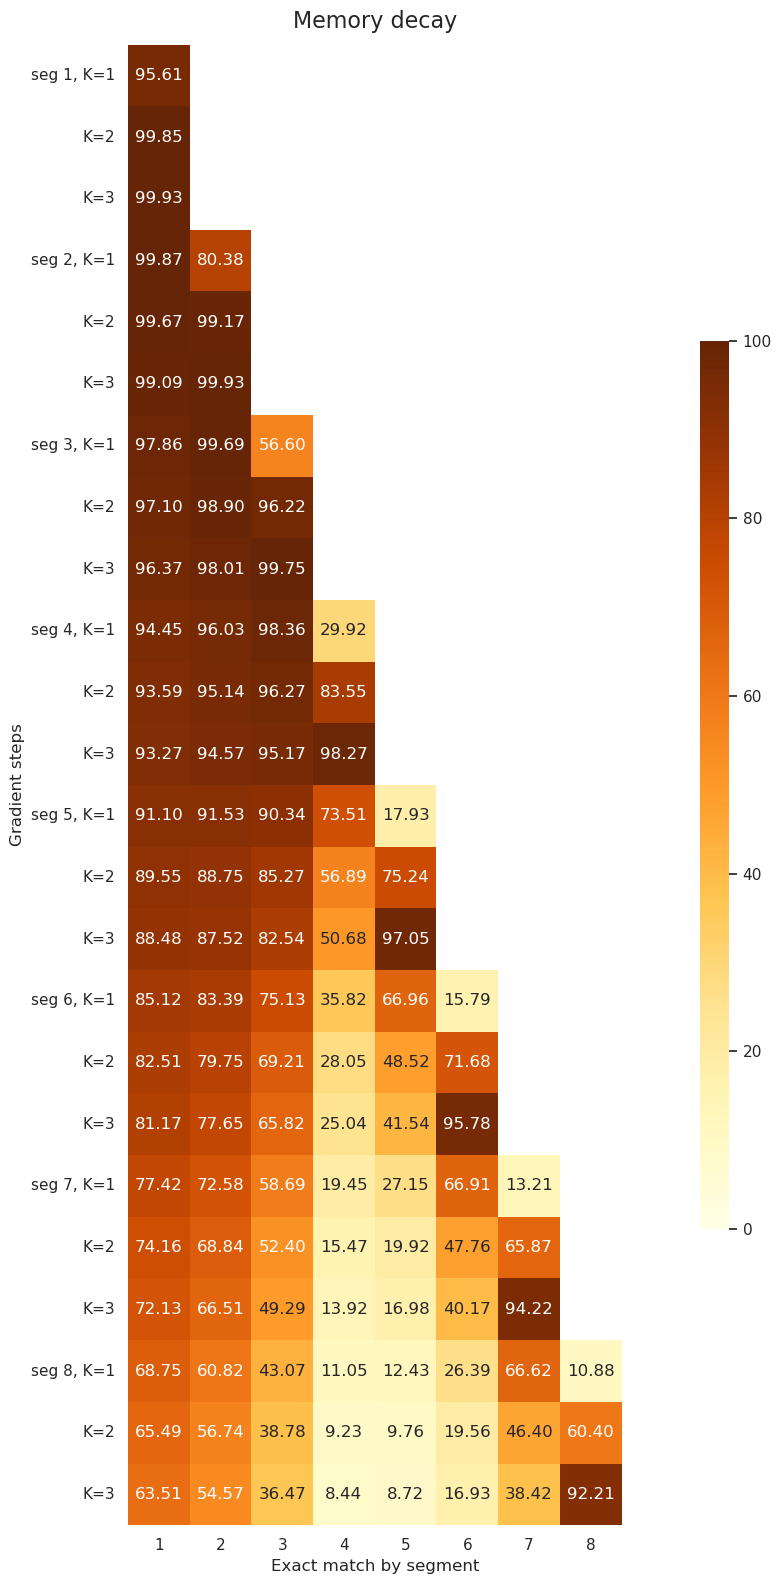

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

data = np.copy(res_exact_match)
data *= 100
mask = data == 0

y_labels = []
for i in range(1, data_args['n_segments'] + 1):
    for j in range(1, model.K + 1):
        if j == 1:
            y_labels.append(f"seg {i}, K={j}")
        else:
            y_labels.append(f"K={j}")

sns.set_theme(style="white")

plt.figure(figsize=(16, 16))
ax = sns.heatmap(
    data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlOrBr",
    cbar_kws={"shrink": 0.6, "aspect": 30},
    square=True,
    vmin=0,
    vmax=100,
)

plt.title("Memory decay", fontsize=16, pad=12)
plt.xlabel("Exact match by segment")
plt.ylabel("Gradient steps")
ax.set_yticklabels(y_labels, rotation=0)
ax.set_xticklabels(range(1, data_args['n_segments'] + 1), rotation=0)

plt.tight_layout()
plt.show()